# 2. Customer Clustering — B2B/B2C Segmentation

This notebook segments customers into **B2B** (business) and **B2C** (consumer)
groups using a feature-based classification approach, then performs **RFM-based
sub-clustering** within each segment using K-Means.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, silhouette_score
import os
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

FIGURES_DIR = os.path.join("..", "results", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

## 2.1 Load & Prepare Data

In [2]:
df = pd.read_csv("../data/sample_sales_data.csv")
df["date"] = pd.to_datetime(df["date"])
df_clean = df[df["sales_amount"] > 0].copy()

# Analysis cutoff: use data up to end-2023 for training, 2024 for validation
CUTOFF_DATE = pd.to_datetime("2024-01-01")
df_hist = df_clean[df_clean["date"] < CUTOFF_DATE].copy()
df_2024 = df_clean[df_clean["date"] >= CUTOFF_DATE].copy()

print(f"Historical data (training): {len(df_hist):,} records ({df_hist['date'].min().date()} → {df_hist['date'].max().date()})")
print(f"Validation data (2024+)   : {len(df_2024):,} records")

# Fill missing product_category using known mappings
item_cat_map = (df_hist.dropna(subset=["product_category"])
                .drop_duplicates("product_code")
                .set_index("product_code")["product_category"].to_dict())
df_hist["product_category"] = df_hist.apply(
    lambda r: item_cat_map.get(r["product_code"], r["product_category"]), axis=1
)
df_hist["product_category"] = df_hist["product_category"].fillna(999).astype(int)

MemoryError: Unable to allocate 5.49 MiB for an array with shape (9, 79935) and data type int64

## 2.2 RFM Feature Engineering

In [ ]:
NOW = CUTOFF_DATE
rfm = df_hist.groupby("customer_code").agg(
    recency=("date", lambda x: (NOW - x.max()).days),
    frequency=("invoice_no", "nunique"),
    monetary=("gross_profit", "sum"),
    total_revenue=("sales_amount", "sum"),
    avg_order_value=("sales_amount", "mean"),
    n_products=("product_code", "nunique"),
    first_purchase=("date", "min"),
    last_purchase=("date", "max"),
).reset_index()

# Customer lifespan in days
rfm["tenure_days"] = (rfm["last_purchase"] - rfm["first_purchase"]).dt.days

# Add customer name for reference
name_map = (df_hist.sort_values("date", ascending=False)
            .drop_duplicates("customer_code")[["customer_code", "customer_name"]])
rfm = pd.merge(rfm, name_map, on="customer_code", how="left")

print(f"Customers in RFM table: {len(rfm)}")
rfm[["customer_name", "recency", "frequency", "monetary"]].head(10)

Customers in RFM table: 276


,customer_name,recency,frequency,monetary
0,Customer_0001,3,1129,77018932
1,Customer_0002,1161,134,1342339
2,Customer_0003,101,349,5404725
3,Customer_0004,7,1447,58034028
4,Customer_0005,3079,30,280643
5,Customer_0006,16,45,730666
6,Customer_0007,1728,481,4435504
7,Customer_0008,3,263,2589368
8,Customer_0276,3,2348,77143426
9,Customer_0010,18,40,2534393


## 2.3 B2B / B2C Classification Features

In [ ]:
# --- Feature 1: Average order quantity per invoice ---
order_qty = (df_hist.groupby(["customer_code", "invoice_no"])["quantity"]
             .sum().reset_index()
             .groupby("customer_code")["quantity"].mean()
             .reset_index().rename(columns={"quantity": "avg_order_qty"}))

# --- Feature 2: Average gross profit per item (unit economics) ---
df_hist["gp_per_item"] = np.where(
    df_hist["quantity"] > 0,
    df_hist["gross_profit"] / df_hist["quantity"],
    0
)
avg_gp_item = (df_hist.groupby("customer_code")["gp_per_item"]
               .mean().reset_index()
               .rename(columns={"gp_per_item": "avg_gp_per_item"}))

# --- Feature 3: Product category diversity (entropy-like) ---
cat_counts = (df_hist.groupby(["customer_code", "product_category"])
              .size().reset_index(name="count"))
cat_diversity = (cat_counts.groupby("customer_code")["product_category"]
                 .nunique().reset_index()
                 .rename(columns={"product_category": "category_diversity"}))

# --- Feature 4: Category-level monetary breakdown ---
cat_monetary = (df_hist.groupby(["customer_code", "product_category"])["gross_profit"]
                .sum().reset_index()
                .pivot(index="customer_code", columns="product_category", values="gross_profit")
                .fillna(0))
cat_monetary.columns = [f"cat_{int(c)}_profit" for c in cat_monetary.columns]

# --- Merge all features ---
features = rfm.copy()
for feat_df in [order_qty, avg_gp_item, cat_diversity]:
    features = pd.merge(features, feat_df, on="customer_code", how="left")
features = pd.merge(features, cat_monetary, on="customer_code", how="left")
features = features.fillna(0)

print(f"Feature matrix: {features.shape}")

Feature matrix: (276, 150)


## 2.4 B2B/B2C Classification with Logistic Regression

We use a semi-supervised approach: manually label a subset based on
observable patterns (high frequency + high volume → B2B), then train
a classifier.

In [ ]:
# --- Heuristic labeling for training set ---
# B2B indicators: high frequency, large order quantities, many product categories
features["b2b_heuristic"] = (
    ((features["frequency"] >= 10) & (features["avg_order_qty"] >= 10)) |
    ((features["frequency"] >= 20) & (features["category_diversity"] >= 5)) |
    (features["monetary"] >= features["monetary"].quantile(0.85))
).astype(int)

print(f"Heuristic B2B: {features['b2b_heuristic'].sum()} / {len(features)} "
      f"({features['b2b_heuristic'].mean()*100:.1f}%)")

Heuristic B2B: 113 / 276 (40.9%)


In [ ]:
# --- Train Logistic Regression ---
feature_cols = ["recency", "frequency", "monetary", "avg_order_qty",
                "avg_gp_per_item", "category_diversity", "n_products",
                "tenure_days", "total_revenue"]
# Add top category columns
cat_cols = [c for c in features.columns if c.startswith("cat_") and c.endswith("_profit")]
feature_cols.extend(cat_cols[:10])  # Top 10 categories

X = features[feature_cols].fillna(0)
y = features["b2b_heuristic"]

scaler_lr = StandardScaler()
X_scaled = scaler_lr.fit_transform(X)

lr_model = LogisticRegression(solver="liblinear", random_state=42, C=1.0)
lr_model.fit(X_scaled, y)

features["b2b_probability"] = lr_model.predict_proba(X_scaled)[:, 1]
features["is_b2b"] = (features["b2b_probability"] >= 0.5).astype(int)

print(f"\n=== B2B/B2C Classification Results ===")
print(f"B2B customers: {features['is_b2b'].sum()} ({features['is_b2b'].mean()*100:.1f}%)")
print(f"B2C customers: {(1-features['is_b2b']).sum()} ({(1-features['is_b2b']).mean()*100:.1f}%)")


=== B2B/B2C Classification Results ===
B2B customers: 115 (41.7%)
B2C customers: 161 (58.3%)


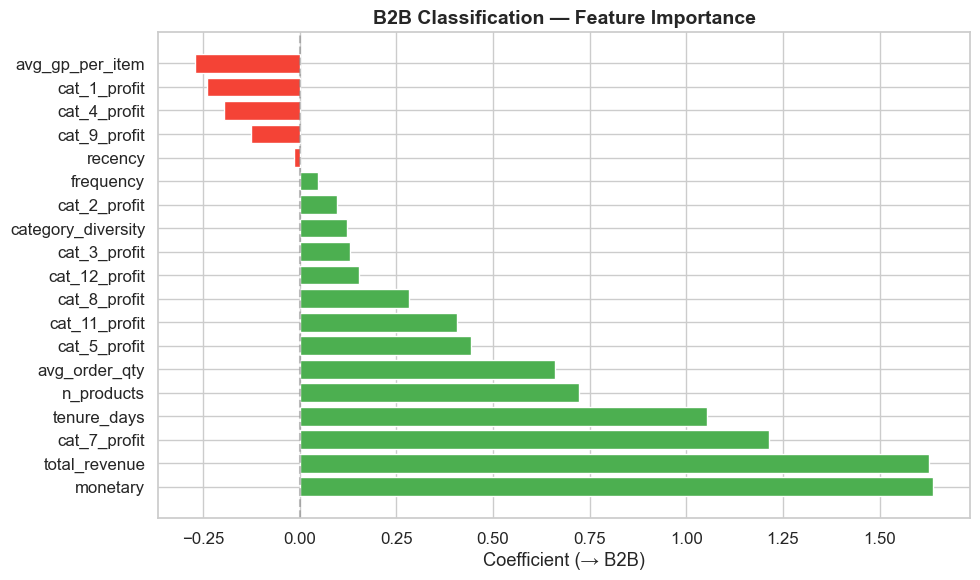

In [ ]:
# --- Feature importance ---
importance = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr_model.coef_[0]
}).sort_values("coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#4CAF50" if c > 0 else "#F44336" for c in importance["coefficient"]]
ax.barh(importance["feature"], importance["coefficient"], color=colors)
ax.set_xlabel("Coefficient (→ B2B)")
ax.set_title("B2B Classification — Feature Importance", fontweight="bold", fontsize=14)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_b2b_feature_importance.png"), bbox_inches="tight")
plt.show()

## 2.5 Sub-Clustering: B2B Segment (K-Means)

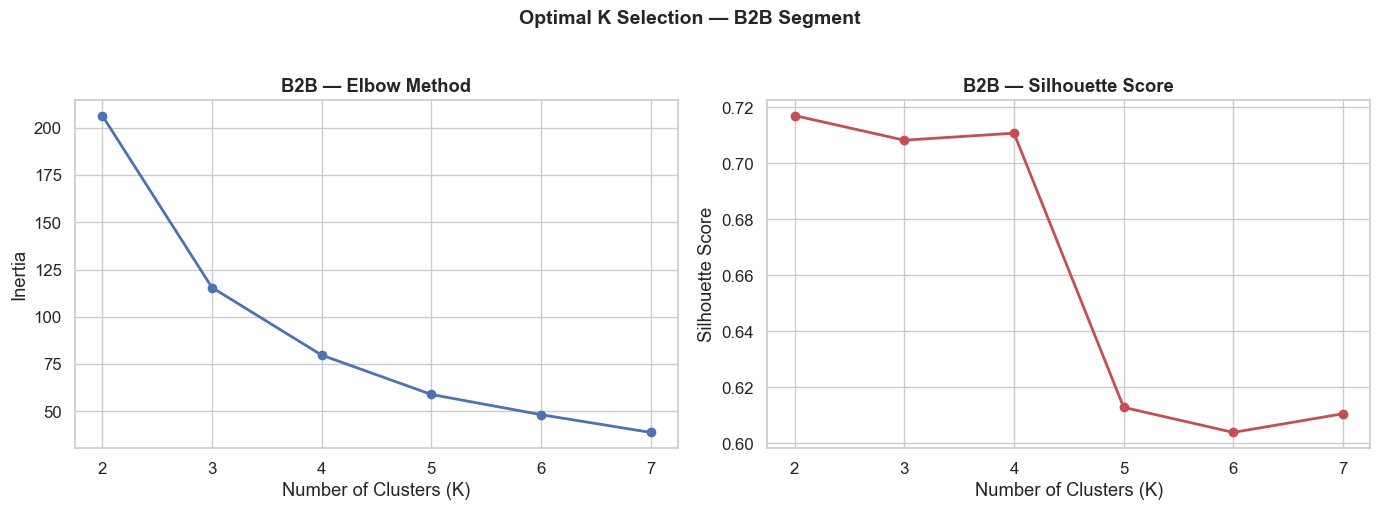

In [ ]:
cluster_features = ["recency", "frequency", "monetary"]

# --- Elbow method for B2B ---
df_b2b = features[features["is_b2b"] == 1].copy()
X_b2b = df_b2b[cluster_features].fillna(0)
X_b2b_scaled = StandardScaler().fit_transform(X_b2b)

inertias_b2b = []
sil_scores_b2b = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_b2b_scaled)
    inertias_b2b.append(km.inertia_)
    sil_scores_b2b.append(silhouette_score(X_b2b_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias_b2b, "bo-", linewidth=2)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("B2B — Elbow Method", fontweight="bold")

axes[1].plot(K_range, sil_scores_b2b, "ro-", linewidth=2)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("B2B — Silhouette Score", fontweight="bold")

plt.suptitle("Optimal K Selection — B2B Segment", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_b2b_elbow.png"), bbox_inches="tight")
plt.show()

In [ ]:
# --- Apply K-Means with optimal K (B2B) ---
K_B2B = 3
kmeans_b2b = KMeans(n_clusters=K_B2B, random_state=42, n_init=10)
df_b2b["cluster"] = kmeans_b2b.fit_predict(X_b2b_scaled)
df_b2b["cluster_label"] = df_b2b["cluster"].apply(lambda x: f"B2B_{x}")

# Cluster summary
b2b_summary = df_b2b.groupby("cluster_label").agg(
    n_customers=("customer_code", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_revenue=("total_revenue", "mean"),
).round(1)

print("=== B2B Cluster Summary ===")
print(b2b_summary.to_string())

=== B2B Cluster Summary ===
               n_customers  avg_recency  avg_frequency  avg_monetary  avg_revenue
cluster_label                                                                    
B2B_0                   12       1846.7           28.5     1136864.0    1136864.0
B2B_1                   94         68.6          162.3     3771449.2    3771449.2
B2B_2                    9        285.7         1137.3    83285319.1   84013167.3


## 2.6 Sub-Clustering: B2C Segment (K-Means)

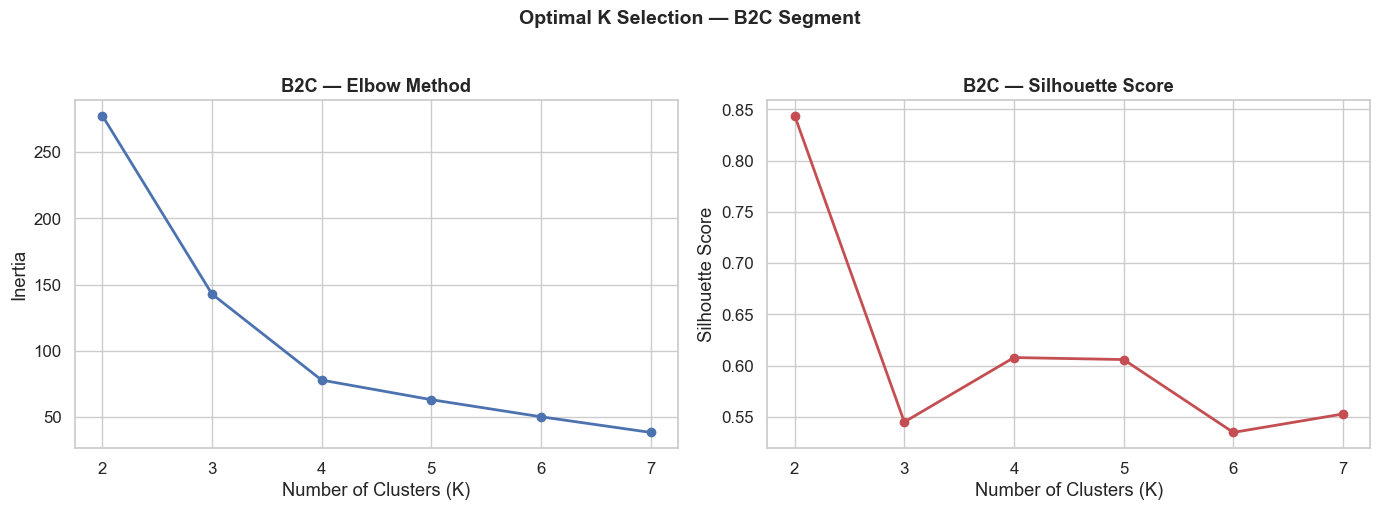

In [ ]:
# --- Elbow method for B2C ---
df_b2c = features[features["is_b2b"] == 0].copy()
X_b2c = df_b2c[cluster_features].fillna(0)
X_b2c_scaled = StandardScaler().fit_transform(X_b2c)

inertias_b2c = []
sil_scores_b2c = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_b2c_scaled)
    inertias_b2c.append(km.inertia_)
    sil_scores_b2c.append(silhouette_score(X_b2c_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias_b2c, "bo-", linewidth=2)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("B2C — Elbow Method", fontweight="bold")

axes[1].plot(K_range, sil_scores_b2c, "ro-", linewidth=2)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("B2C — Silhouette Score", fontweight="bold")

plt.suptitle("Optimal K Selection — B2C Segment", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_b2c_elbow.png"), bbox_inches="tight")
plt.show()

In [ ]:
# --- Apply K-Means with optimal K (B2C) ---
K_B2C = 4
kmeans_b2c = KMeans(n_clusters=K_B2C, random_state=42, n_init=10)
df_b2c["cluster"] = kmeans_b2c.fit_predict(X_b2c_scaled)
df_b2c["cluster_label"] = df_b2c["cluster"].apply(lambda x: f"B2C_{x}")

b2c_summary = df_b2c.groupby("cluster_label").agg(
    n_customers=("customer_code", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_revenue=("total_revenue", "mean"),
).round(1)

print("=== B2C Cluster Summary ===")
print(b2c_summary.to_string())

=== B2C Cluster Summary ===
               n_customers  avg_recency  avg_frequency  avg_monetary  avg_revenue
cluster_label                                                                    
B2C_0                   63       2364.6            8.7       63846.9      63846.9
B2C_1                    2        865.5          390.0     4425000.5    4425000.5
B2C_2                   81        286.2           10.0      103997.5     103997.5
B2C_3                   15        840.8          105.6      910528.1     910528.1


## 2.7 Cluster Visualization

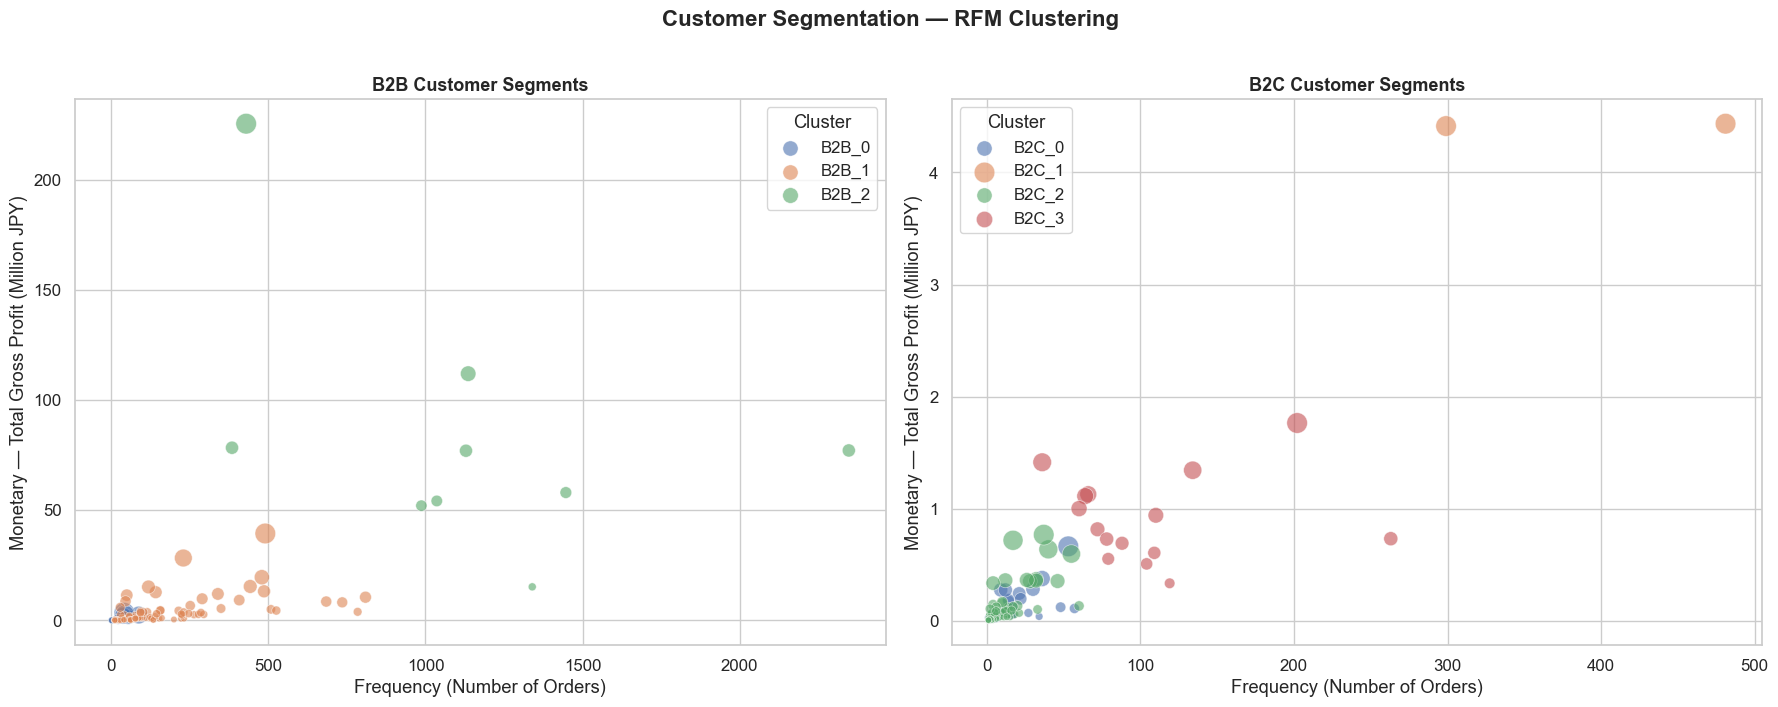

In [ ]:
# Combine all clusters
all_clusters = pd.concat([df_b2b, df_b2c])

# --- 3D-style scatter: Frequency vs Monetary colored by cluster ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# B2B
for label in sorted(df_b2b["cluster_label"].unique()):
    subset = df_b2b[df_b2b["cluster_label"] == label]
    axes[0].scatter(subset["frequency"], subset["monetary"] / 1e6,
                    alpha=0.6, s=subset["total_revenue"] / subset["total_revenue"].max() * 200 + 20,
                    label=label, edgecolors="white", linewidth=0.5)
axes[0].set_xlabel("Frequency (Number of Orders)")
axes[0].set_ylabel("Monetary — Total Gross Profit (Million JPY)")
axes[0].set_title("B2B Customer Segments", fontweight="bold", fontsize=13)
axes[0].legend(title="Cluster")

# B2C
for label in sorted(df_b2c["cluster_label"].unique()):
    subset = df_b2c[df_b2c["cluster_label"] == label]
    axes[1].scatter(subset["frequency"], subset["monetary"] / 1e6,
                    alpha=0.6, s=subset["total_revenue"] / subset["total_revenue"].max() * 200 + 20,
                    label=label, edgecolors="white", linewidth=0.5)
axes[1].set_xlabel("Frequency (Number of Orders)")
axes[1].set_ylabel("Monetary — Total Gross Profit (Million JPY)")
axes[1].set_title("B2C Customer Segments", fontweight="bold", fontsize=13)
axes[1].legend(title="Cluster")

plt.suptitle("Customer Segmentation — RFM Clustering", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_cluster_scatter.png"), bbox_inches="tight")
plt.show()

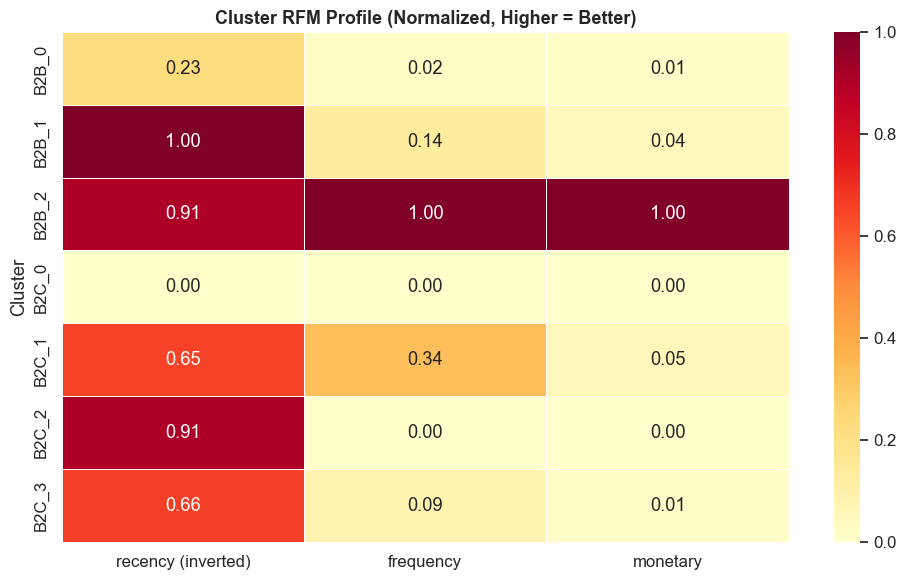

In [ ]:
# --- Heatmap: cluster centroids (normalized) ---
cluster_summary = all_clusters.groupby("cluster_label")[cluster_features].mean()
# Normalize each feature to 0-1 scale for heatmap
cluster_norm = (cluster_summary - cluster_summary.min()) / (cluster_summary.max() - cluster_summary.min())
# Invert recency so that lower = better
cluster_norm["recency"] = 1 - cluster_norm["recency"]
cluster_norm = cluster_norm.rename(columns={"recency": "recency (inverted)"})

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cluster_norm, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title("Cluster RFM Profile (Normalized, Higher = Better)", fontweight="bold", fontsize=13)
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_cluster_heatmap.png"), bbox_inches="tight")
plt.show()

## 2.8 Cluster Interpretation & Naming

In [ ]:
# Assign descriptive names based on RFM patterns
full_summary = all_clusters.groupby("cluster_label").agg(
    n=("customer_code", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_monetary=("monetary", "sum"),
    avg_revenue=("total_revenue", "mean"),
).sort_values("avg_monetary", ascending=False)

full_summary["revenue_share_%"] = (full_summary["total_monetary"]
                                    / full_summary["total_monetary"].sum() * 100).round(1)

print("=" * 80)
print("FINAL CLUSTER SUMMARY")
print("=" * 80)
print(full_summary.round(1).to_string())
print()
print("Key Insight: The top cluster(s) by monetary value are 'Royal Customers'")
print("These customers will be prioritized in the inventory optimization model.")

FINAL CLUSTER SUMMARY
                n  avg_recency  avg_frequency  avg_monetary  total_monetary  avg_revenue  revenue_share_%
cluster_label                                                                                            
B2B_2           9        285.7         1137.3    83285319.1       749567872   84013167.3             65.0
B2C_1           2        865.5          390.0     4425000.5         8850001    4425000.5              0.8
B2B_1          94         68.6          162.3     3771449.2       354516228    3771449.2             30.8
B2B_0          12       1846.7           28.5     1136864.0        13642368    1136864.0              1.2
B2C_3          15        840.8          105.6      910528.1        13657922     910528.1              1.2
B2C_2          81        286.2           10.0      103997.5         8423795     103997.5              0.7
B2C_0          63       2364.6            8.7       63846.9         4022357      63846.9              0.3

Key Insight: The top cl

In [ ]:
# --- Save cluster assignments for downstream notebooks ---
cluster_export = all_clusters[["customer_code", "customer_name", "is_b2b",
                                "cluster_label", "recency", "frequency", "monetary",
                                "total_revenue", "b2b_probability"]].copy()
cluster_export.to_csv("../data/customer_clusters.csv", index=False)
print(f"✅ Saved cluster assignments: ../data/customer_clusters.csv ({len(cluster_export)} customers)")

✅ Saved cluster assignments: ../data/customer_clusters.csv (276 customers)


## 2.9 Summary

| Segment | Clusters | Description |
|---------|----------|-------------|
| B2B | 3 sub-clusters | Businesses segmented by order scale & loyalty |
| B2C | 4 sub-clusters | Individual consumers segmented by purchase behavior |

The highest-value cluster is identified as **"Royal Customers"** and will
receive priority allocation during supply shortages in the inventory
optimization simulation (Notebook 04).